# Análisis predictivo de datos - Evaluación 1

**Condiciones de entrega de la evaluación:**

- Debe entregar un archivo en formato .ipynb.
- El código debe correr correctamente cuando las celdas se ejecutan de manera secuencial.
- Debe entregar el código ya ejecutado.
- Elimine previamente todo el código que sea basura, solo entregue el código que de respuesta a lo que se le pide que haga.

Con el archivo de datos suministrado, va a crear un modelo de aprendizaje de máquina que prediga la variable **Weight**. Para escoger el modelo a utilizar se debe tener en cuenta que esta variable es **numérica** o **cuantitativa**.

Información sobre este archivo, incluido el diccionario de datos, la puede obtener en [Kaggle](https://www.kaggle.com/datasets/samruddhim/olympics-althlete-events-analysis).

## Carga y comprensión de los datos

Abra el archivo de datos en Excel o bloc de notas, y revise sí hay algo particular con los datos. Este paso es importante para evitar problemas posteriores al cargar los datos.

Cargue en `Pandas` el archivo de datos.

Indique cuántas variables y registros tiene el dataset, y asegúrese que el tipo de dato de cada variable sea el esperado.

Reporte las estadísticas descriptivas de las variables numéricas y categóricas.

Identifique si el dataframe tiene datos duplicados.

Identifique si hay variables con datos nulos.

Reporte los hallazgos en un celda de texto.

In [85]:
from pathlib import Path

import pandas as pd

DATA_DIR = Path().resolve().parent / 'data' / 'raw'
file_name = 'athlete_events.csv'
file_path = DATA_DIR / file_name

df = pd.read_csv(file_path)
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


Games es una variable redundante.

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


In [87]:
df.describe()

,ID,Age,Height,Weight,Year
count,271116.000000,261642.000000,210945.000000,208241.000000,271116.000000
mean,68248.954396,25.556898,175.338970,70.702393,1978.378480
std,39022.286345,6.393561,10.518462,14.348020,29.877632
min,1.000000,10.000000,127.000000,25.000000,1896.000000
25%,34643.000000,21.000000,168.000000,60.000000,1960.000000
50%,68205.000000,24.000000,175.000000,70.000000,1988.000000
75%,102097.250000,28.000000,183.000000,79.000000,2002.000000
max,135571.000000,97.000000,226.000000,214.000000,2016.000000


ID es una variable categórica.

In [88]:
df['ID'] = df['ID'].astype('object')

In [89]:
df.describe(include='object')

,ID,Name,Sex,Team,NOC,Games,Season,City,Sport,Event,Medal
count,271116,271116,271116,271116,271116,271116,271116,271116,271116,271116,39783
unique,135571,134732,2,1184,230,51,2,42,66,765,3
top,77710,Robert Tait McKenzie,M,United States,USA,2000 Summer,Summer,London,Athletics,Football Men's Football,Gold
freq,58,58,196594,17847,18853,13821,222552,22426,38624,5733,13372


ID y Names son cuasi claves primaris. Deben descartarse.
Team, Event, NOC, Sport Games y City tienen muy alta cardinalidad.

In [90]:
df.isnull().sum()*100 / len(df)

ID         0.000000
Name       0.000000
Sex        0.000000
Age        3.494445
Height    22.193821
Weight    23.191180
Team       0.000000
NOC        0.000000
Games      0.000000
Year       0.000000
Season     0.000000
City       0.000000
Sport      0.000000
Event      0.000000
Medal     85.326207
dtype: float64

La variable objetivo tiene datos nulos; estos deben descartarse.

In [91]:
print('Duplicados:', df.duplicated().sum())

Duplicados: 1385


Descarte las variables que considere irrelevantes para su modelo (p.e. claves primarias, variables con valores únicos, variables redundantes, entre otros).

Gestione los datos duplicados y los datos nulos. En el caso de la variable **Medal**, impute a los datos nulos el valor **No medal**.

In [92]:
df = df.fillna({'Medal': 'No medal'})
df.isnull().sum()*100 / len(df)

ID         0.000000
Name       0.000000
Sex        0.000000
Age        3.494445
Height    22.193821
Weight    23.191180
Team       0.000000
NOC        0.000000
Games      0.000000
Year       0.000000
Season     0.000000
City       0.000000
Sport      0.000000
Event      0.000000
Medal      0.000000
dtype: float64

In [93]:
df['Medal'].value_counts()

Medal
No medal    231333
Gold         13372
Bronze       13295
Silver       13116
Name: count, dtype: int64

In [94]:
df = df.drop(columns=['ID', 'Name', 'Games'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 12 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Sex     271116 non-null  object 
 1   Age     261642 non-null  float64
 2   Height  210945 non-null  float64
 3   Weight  208241 non-null  float64
 4   Team    271116 non-null  object 
 5   NOC     271116 non-null  object 
 6   Year    271116 non-null  int64  
 7   Season  271116 non-null  object 
 8   City    271116 non-null  object 
 9   Sport   271116 non-null  object 
 10  Event   271116 non-null  object 
 11  Medal   271116 non-null  object 
dtypes: float64(3), int64(1), object(8)
memory usage: 24.8+ MB


In [95]:
df = df.dropna(subset=['Weight'])
df.isnull().sum()*100 / len(df)

Sex       0.000000
Age       0.413943
Height    0.666535
Weight    0.000000
Team      0.000000
NOC       0.000000
Year      0.000000
Season    0.000000
City      0.000000
Sport     0.000000
Event     0.000000
Medal     0.000000
dtype: float64

Descartando datos nulos de Weight, la proporción de datos nulos que quedan es muy baja, así que también pueden descartarse.

In [96]:
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 206165 entries, 0 to 271115
Data columns (total 12 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Sex     206165 non-null  object 
 1   Age     206165 non-null  float64
 2   Height  206165 non-null  float64
 3   Weight  206165 non-null  float64
 4   Team    206165 non-null  object 
 5   NOC     206165 non-null  object 
 6   Year    206165 non-null  int64  
 7   Season  206165 non-null  object 
 8   City    206165 non-null  object 
 9   Sport   206165 non-null  object 
 10  Event   206165 non-null  object 
 11  Medal   206165 non-null  object 
dtypes: float64(3), int64(1), object(8)
memory usage: 20.4+ MB


Finalmente, se descartan duplicados:

In [97]:
df = df.drop_duplicates()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 205846 entries, 0 to 271115
Data columns (total 12 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Sex     205846 non-null  object 
 1   Age     205846 non-null  float64
 2   Height  205846 non-null  float64
 3   Weight  205846 non-null  float64
 4   Team    205846 non-null  object 
 5   NOC     205846 non-null  object 
 6   Year    205846 non-null  int64  
 7   Season  205846 non-null  object 
 8   City    205846 non-null  object 
 9   Sport   205846 non-null  object 
 10  Event   205846 non-null  object 
 11  Medal   205846 non-null  object 
dtypes: float64(3), int64(1), object(8)
memory usage: 20.4+ MB


## Análisis exploratorio de variables categóricas

Haga un análisis de las variables categóricas no descartadas, e identifique:

- Variables nominales.
- Variables ordinales.
- Variables con alta cardinalidad.
- Variables que no deberían incluirse en la matriz de características.
- Indiquen qué tipo de procesamiento debería recibir cada una de las variables categóricas, según su tipo y cardinalidad.

Reporte los resultados del análisis en una celda de texto.

In [98]:
cat_vars = df.select_dtypes(include='object').columns
for var in cat_vars:
    print(f'{var}:\n {df[var].unique()} unique values \n')

Sex:
 ['M' 'F'] unique values 

Team:
 ['China' 'Netherlands' 'United States' 'Finland' 'Norway' 'Romania'
 'Estonia' 'France' 'Spain' 'Egypt' 'Bulgaria' 'Italy' 'Azerbaijan'
 'Russia' 'Argentina' 'Cuba' 'Belarus' 'Greece' 'Cameroon' 'Mexico'
 'Soviet Union' 'Nicaragua' 'Hungary' 'Nigeria' 'Algeria' 'Kuwait'
 'Bahrain' 'Pakistan' 'Iraq' 'Lebanon' 'Qatar' 'Malaysia' 'Iran' 'Canada'
 'Ireland' 'Australia' 'South Africa' 'Morocco' 'Eritrea' 'Tanzania'
 'Jordan' 'Sudan' 'Tunisia' 'Libya' 'Belgium' 'Djibouti' 'Comoros'
 'Kazakhstan' 'Brunei' 'Saudi Arabia' 'Maldives' 'Ethiopia' 'Indonesia'
 'Philippines' 'Uzbekistan' 'United Arab Emirates' 'Kyrgyzstan'
 'Tajikistan' 'Unified Team' 'Japan' 'Japan-1' 'Brazil' 'West Germany'
 'East Germany' 'Germany' 'Israel' 'Sweden' 'United States Virgin Islands'
 'Turkey' 'Sri Lanka' 'Armenia' "Cote d'Ivoire" 'Kenya' 'Benin' 'France-1'
 'Ukraine' 'Ghana' 'Somalia' 'Latvia' 'Syria' 'Great Britain' 'Chile'
 'Switzerland' 'India' 'Poland' 'Costa Rica' 'Panama'

In [99]:
print(cat_vars)

Index(['Sex', 'Team', 'NOC', 'Season', 'City', 'Sport', 'Event', 'Medal'], dtype='object')


**Nominales:** Sex, Team, NOC, Season, City, Sport, Event
Variables de baja cardinalidad se pueden codificar One-Hot Encoding. Las de alta es mejor codificarlas con Target Encoding.

**Ordinal:** Medal. Esta debe codificarse con Ordinal Encoder.

In [100]:
Teams = df['Team'].value_counts().sort_values(ascending=False)
print('Teams with less than 5 athletes:', Teams[Teams <= 5].sum())

Teams with less than 5 athletes: 725


Team tiene muchas categorías extremadamente atípicas. Podría considerarse descartar esta variable.

In [101]:
NOC = df['NOC'].value_counts().sort_values(ascending=False)
print('NOCs with less than 5 athletes:', NOC[NOC <= 5].sum())

NOCs with less than 5 athletes: 14


También NOC tiene categorías atípicas.

In [102]:
Events =df['Event'].value_counts().sort_values(ascending=False).tail(30)
print('Events with less than 5 participants:', Events[Events <= 5].sum())

Events with less than 5 participants: 34


Events también tiene categorías atípicas.

Podrían descartarse las categorías atípicas de Team, NOC y Event.

In [103]:
Atypical_teams = Teams[Teams <= 5].index.tolist()
print('Atypical teams:', Atypical_teams)

Atypical teams: ['United States Virgin Islands-2', 'Daisy', 'Lucky Star', 'Toronto Argonauts', 'Barco Deloro', 'West Germany-3', 'Unified Team-3', 'Studenternes Roklub-2', 'Israel-1', 'Greece-1', 'Greece-2', 'Buraddoo', 'Czechoslovakia-3', 'Bulgaria-1', 'Thailand-2', 'Spirit III', 'Thailand-1', 'Espuma del Mar', 'Ireland-2', 'Subbnboana', 'United States Virgin Islands-1', 'Tuvalu', 'Danuta', 'Macky VI', 'Rush VII', 'Web II', 'White Lady', 'Snude', 'Kuling', 'Bim', 'Boreas', 'Argo II', 'Rush IV', 'Web III', 'Lett', 'Gabbiano', 'Dinah V', 'Aletta', 'Monica', 'Posillipo III', 'Bronia', 'Argeste', 'Miss Nippon V', 'Olen', 'Xolotl', 'Yeoman VII', 'Yeoman XII', 'Fram III', 'Baccara', 'Roy', 'Mutafo', 'Salamander', 'Bellatrix IX', 'Snowten III', 'Viktoriya', 'Astrid III', 'Alain IV', 'Ireland-1', 'South Sudan', 'Andromeda', 'Chok', 'Grifo III', 'Bingo', 'Damoiselle IV', 'Minotaur', 'Serendipity', 'State VI', 'New York Athletic Club', 'Grifone', 'Venilia', 'Persey', 'Canopus', 'Bajazzo', 'Berm

In [104]:
df_cleaned = df[~df['Team'].isin(Atypical_teams)]
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 205121 entries, 0 to 271115
Data columns (total 12 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Sex     205121 non-null  object 
 1   Age     205121 non-null  float64
 2   Height  205121 non-null  float64
 3   Weight  205121 non-null  float64
 4   Team    205121 non-null  object 
 5   NOC     205121 non-null  object 
 6   Year    205121 non-null  int64  
 7   Season  205121 non-null  object 
 8   City    205121 non-null  object 
 9   Sport   205121 non-null  object 
 10  Event   205121 non-null  object 
 11  Medal   205121 non-null  object 
dtypes: float64(3), int64(1), object(8)
memory usage: 20.3+ MB


In [105]:
NOC = df_cleaned['NOC'].value_counts().sort_values(ascending=False)
print('NOCs with less than 5 athletes:', NOC[NOC <= 5].sum())

Atypical_nocs = NOC[NOC <= 5].index.tolist()
print('Atypical NOCs:', Atypical_nocs)

NOCs with less than 5 athletes: 0
Atypical NOCs: []


In [106]:
Events =df_cleaned['Event'].value_counts().sort_values(ascending=False)
print('Events with less than 5 participants:', Events[Events <= 5].sum())

Events with less than 5 participants: 122


In [107]:
Atypical_events = Events[Events <= 5].index.tolist()
print('Atypical events:', Atypical_events)

Atypical events: ["Cycling Men's 5,000 metres", "Athletics Men's 200 metres Hurdles", "Weightlifting Men's Unlimited, One Hand", "Swimming Men's 4 x 250 metres Freestyle Relay", "Gymnastics Men's Individual All-Around, Field Sports", "Athletics Men's 3,500 metres Walk", "Gymnastics Men's Individual All-Around, Apparatus Work", "Athletics Men's Standing Triple Jump", "Athletics Men's 2,590 metres Steeplechase", "Cycling Men's 333 metres Time Trial", "Bobsleigh Men's Four/Five", 'Art Competitions Mixed Painting, Unknown Event', "Swimming Men's One Mile Freestyle", "Athletics Men's 2,500 metres Steeplechase", "Cycling Men's 20 kilometres", "Cycling Men's 50 kilometres", "Gymnastics Men's Rope Climbing", "Athletics Men's 4,000 metres Steeplechase", "Wrestling Men's Middleweight A, Greco-Roman", "Shooting Men's Free Rifle, 400, 600 and 800 metres, Team", 'Art Competitions Mixed Architecture, Architectural Designs', "Shooting Men's Trap, Team", "Speed Skating Men's Allround", "Canoeing Men's

In [108]:
df_cleaned = df_cleaned[~df_cleaned['Event'].isin(Atypical_events)]
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 204999 entries, 0 to 271115
Data columns (total 12 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Sex     204999 non-null  object 
 1   Age     204999 non-null  float64
 2   Height  204999 non-null  float64
 3   Weight  204999 non-null  float64
 4   Team    204999 non-null  object 
 5   NOC     204999 non-null  object 
 6   Year    204999 non-null  int64  
 7   Season  204999 non-null  object 
 8   City    204999 non-null  object 
 9   Sport   204999 non-null  object 
 10  Event   204999 non-null  object 
 11  Medal   204999 non-null  object 
dtypes: float64(3), int64(1), object(8)
memory usage: 20.3+ MB


## Análisis exploratorio de variables cuantitativas o numéricas

Haga un análisis de las variables cuantitativas no descartadas, e identifique:

- Variables que son aproximadamente normales.
- Variables con datos atípicos.
- Variables que no deberían incluirse en la matriz de características.
- Indique qué tipo de procesamiento debería recibir cada una de las variables numéricas, según su distribución y la presencia de valores atípicos.

Reporte los resultados del análisis en una celda de texto.

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Height'}>],
       [<Axes: title={'center': 'Weight'}>,
        <Axes: title={'center': 'Year'}>]], dtype=object)

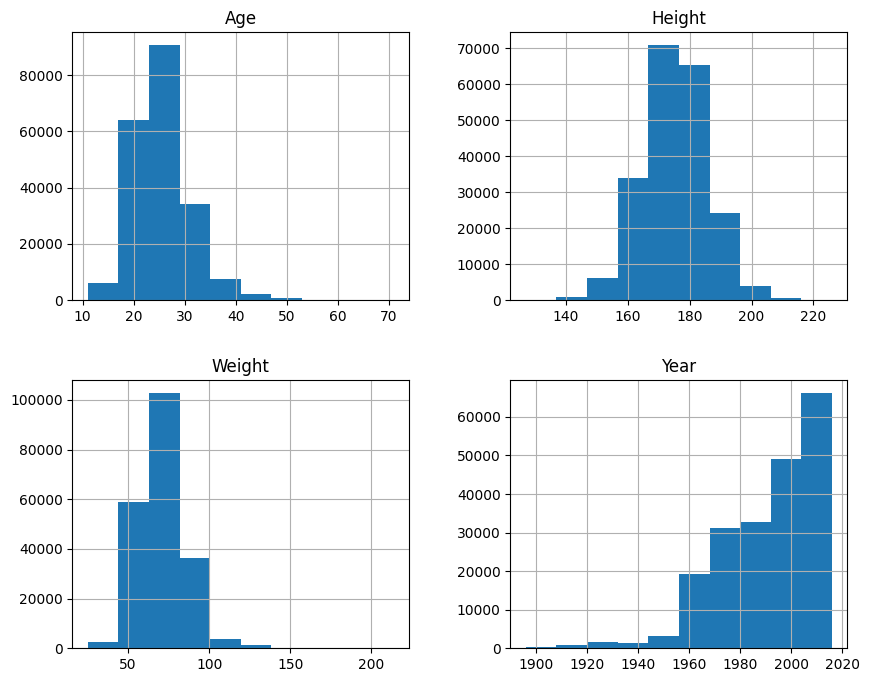

In [109]:
df.hist(figsize=(10, 8))

Age          Axes(0.125,0.11;0.168478x0.77)
Height    Axes(0.327174,0.11;0.168478x0.77)
Weight    Axes(0.529348,0.11;0.168478x0.77)
Year      Axes(0.731522,0.11;0.168478x0.77)
dtype: object

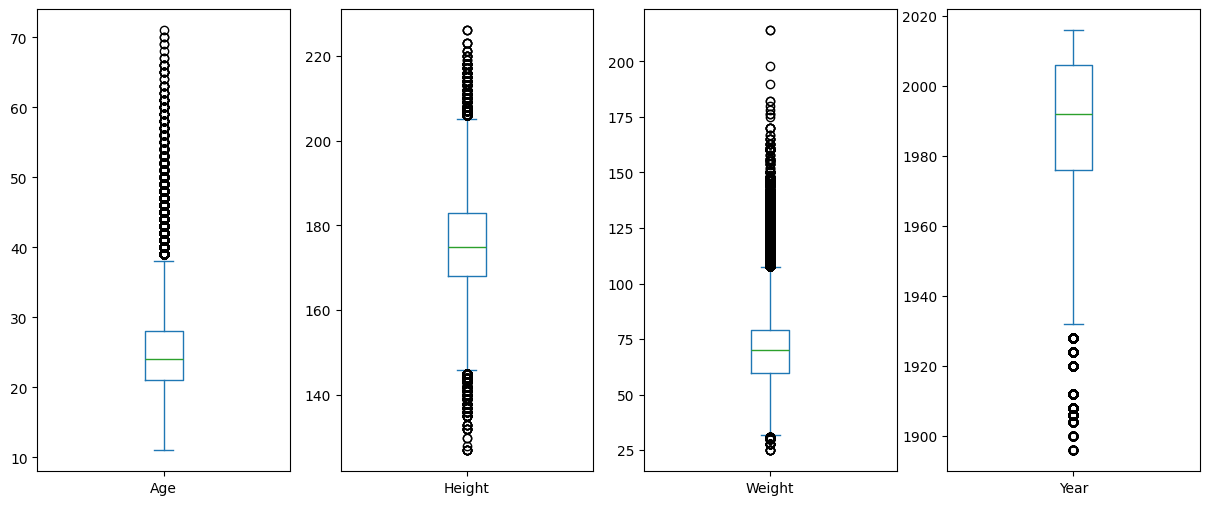

In [110]:
df.plot(kind='box', figsize=(15, 6), subplots=True)

Age y Height son normales, se pueden estandarizar. Weight también es normal, pero como es la variable objetivo, no se procesa.

Year no es normal, lo mejor es normalizarla.

Todas las variables tienen datos atípicos, pero no son extremos; si el modelo no da buenos resultados, podría considerarse eliminarlos.

## Procesamiento de las características y entrenamiento del modelo

- Escoja un modelo de árbol de decisión que prediga la variable **Weight**, teniendo en cuenta que es numérica continua.
- Extraiga la matriz de características y el vector objetivo de su dataframe, a partir de los análisis previos.
- Parta los datos en subconjuntos de entrenamiento y de prueba.
- Procese las características del modelo usando `ColumnTransformer`.
- Entrene el modelo.
- Reporten los **scores** de entrenamiento y de prueba.
- Reporten el listado completo de características con las que fue entrenado el modelo después del procesamiento realizado.

In [111]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Weight'])
y = df['Weight']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [112]:
X_train.columns

Index(['Sex', 'Age', 'Height', 'Team', 'NOC', 'Year', 'Season', 'City',
       'Sport', 'Event', 'Medal'],
      dtype='object')

In [113]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    TargetEncoder,
)

ohe = OneHotEncoder(drop='if_binary', sparse_output=False)
ordinal = OrdinalEncoder(categories=[['No medal', 'Bronze', 'Silver', 'Gold']])
te = TargetEncoder()
scaler = StandardScaler()
minmax = MinMaxScaler()

preprocessor = ColumnTransformer(transformers=[
    ('ohe', ohe, ['Sex', 'Season']),
    ('ordinal', ordinal, ['Medal']),
    ('te', te, ['Team', 'NOC', 'Event', 'Sport', 'City']),
    ('scaler', scaler, ['Age', 'Height']),
    ('minmax', minmax, ['Year'])
], remainder='drop')

In [114]:
X_train_processed = preprocessor.fit_transform(X_train, y_train)
X_test_processed = preprocessor.transform(X_test)

In [115]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(random_state=42, max_depth=5)
tree.fit(X_train_processed, y_train)
print('Train score:', tree.score(X_train_processed, y_train))
print('Test score:', tree.score(X_test_processed, y_test))

Train score: 0.7994527161226941
Test score: 0.80159899240922


In [116]:
print('model features:', preprocessor.get_feature_names_out())

model features: ['ohe__Sex_M' 'ohe__Season_Winter' 'ordinal__Medal' 'te__Team' 'te__NOC'
 'te__Event' 'te__Sport' 'te__City' 'scaler__Age' 'scaler__Height'
 'minmax__Year']
